# Notebook 01: Baselines

Antes de entrenar cualquier red neuronal, necesitamos establecer los **modelos de referencia** (baselines). Son modelos simples contra los que compararemos todo lo demás.

**Regla fundamental**: si una red neuronal no bate consistentemente a estos baselines, no aporta valor real.

## Baselines que vamos a evaluar

1. **Buy & Hold**: predice retorno = 0 para todos los activos. La estrategia más pasiva posible.
2. **Persistencia**: predice que el retorno futuro = último retorno observado.
3. **Media histórica**: predice que el retorno futuro = media de la ventana de entrada.
4. **Regresión lineal**: el baseline del profesor. Aplana X y ajusta una regresión lineal multivariante.

## Lo que obtendremos al final

- 4 matrices 4×4 con el MAE en test de cada baseline (una por modelo).
- Una comparación visual entre los 4 baselines.
- Los resultados guardados en  para usarlos como referencia en notebooks posteriores.


## 1. Imports

In [ ]:
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import cargar_returns, preparar_datos, TICKERS
from src.baselines import (
    predecir_persistencia,
    predecir_media_historica,
    predecir_buy_and_hold,
    RegresionLinealMultiple,
)
from src.evaluation import mae_global, mae_por_activo, construir_matriz_resultados
from src.plotting import plot_heatmap_mae, plot_comparacion_modelos, plot_mae_por_activo

Imports OK


## 2. Cargar datos

In [4]:
returns = cargar_returns(verbose=True)
print(f"Rango de fechas: {returns.index.min().date()} → {returns.index.max().date()}")
print(f"Activos: {list(returns.columns)}")

[cargar_returns] Cargados 16192 días, 23 activos
Rango de fechas: 1962-01-03 → 2026-05-05
Activos: ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


## 3. Configuración de ventanas

Definimos las 16 combinaciones de ventanas que pide el taller.
Cada combinación (V, H) generará un conjunto de datos diferente.

In [5]:
# Las 4 ventanas de entrada y salida del taller
INPUT_WINDOWS  = [5, 10, 30, 90]   # V: días de historia que mira la red
OUTPUT_WINDOWS = [1, 5, 30, 90]    # H: días a futuro que predice

print(f"Combinaciones totales: {len(INPUT_WINDOWS) * len(OUTPUT_WINDOWS)}")
print()
for V in INPUT_WINDOWS:
    for H in OUTPUT_WINDOWS:
        datos = preparar_datos(returns, V, H, verbose=False)
        n_tr = len(datos["X_train"])
        n_va = len(datos["X_val"])
        n_te = len(datos["X_test"])
        print(f"  V={V:2d}, H={H:2d} → train={n_tr}, val={n_va}, test={n_te}")

Combinaciones totales: 16

  V= 5, H= 1 → train=13840, val=728, test=1619
  V= 5, H= 5 → train=13837, val=728, test=1618
  V= 5, H=30 → train=13815, val=727, test=1616
  V= 5, H=90 → train=13764, val=724, test=1610
  V=10, H= 1 → train=13836, val=728, test=1618
  V=10, H= 5 → train=13832, val=728, test=1618
  V=10, H=30 → train=13811, val=727, test=1615
  V=10, H=90 → train=13760, val=724, test=1609
  V=30, H= 1 → train=13819, val=727, test=1616
  V=30, H= 5 → train=13815, val=727, test=1616
  V=30, H=30 → train=13794, val=726, test=1613
  V=30, H=90 → train=13743, val=723, test=1607
  V=90, H= 1 → train=13767, val=725, test=1610
  V=90, H= 5 → train=13764, val=724, test=1610
  V=90, H=30 → train=13743, val=723, test=1607
  V=90, H=90 → train=13691, val=721, test=1601


## 4. Evaluación de baselines en las 16 combinaciones

El siguiente bucle entrena y evalúa los 4 baselines para cada combinación de ventanas.
Para los modelos no neuronales (persistencia, media, buy & hold) no hay entrenamiento real:
solo calculamos directamente la predicción y medimos el MAE.
Para la regresión lineal sí hay un ajuste (mínimos cuadrados), pero es instantáneo.

Al terminar tendremos una lista  con un dict por cada combinación y modelo.

In [6]:
from tqdm import tqdm

resultados = []

combinaciones = [(V, H) for V in INPUT_WINDOWS for H in OUTPUT_WINDOWS]

for V, H in tqdm(combinaciones, desc="Combinaciones"):

    # Preparar datos para esta combinación
    datos = preparar_datos(returns, V, H, verbose=False)
    X_tr  = datos["X_train"];  y_tr  = datos["y_train"]
    X_val = datos["X_val"];    y_val = datos["y_val"]
    X_te  = datos["X_test"];   y_te  = datos["y_test"]

    # ── Baseline 1: Buy & Hold ──────────────────────────────
    pred_tr  = predecir_buy_and_hold(X_tr)
    pred_val = predecir_buy_and_hold(X_val)
    pred_te  = predecir_buy_and_hold(X_te)
    resultados.append({
        "modelo": "Buy & Hold", "V": V, "H": H,
        "MAE_train": mae_global(y_tr,  pred_tr),
        "MAE_val":   mae_global(y_val, pred_val),
        "MAE_test":  mae_global(y_te,  pred_te),
        "n_params":  0,
    })

    # ── Baseline 2: Persistencia ────────────────────────────
    pred_tr  = predecir_persistencia(X_tr)
    pred_val = predecir_persistencia(X_val)
    pred_te  = predecir_persistencia(X_te)
    resultados.append({
        "modelo": "Persistencia", "V": V, "H": H,
        "MAE_train": mae_global(y_tr,  pred_tr),
        "MAE_val":   mae_global(y_val, pred_val),
        "MAE_test":  mae_global(y_te,  pred_te),
        "n_params":  0,
    })

    # ── Baseline 3: Media histórica ─────────────────────────
    pred_tr  = predecir_media_historica(X_tr)
    pred_val = predecir_media_historica(X_val)
    pred_te  = predecir_media_historica(X_te)
    resultados.append({
        "modelo": "Media histórica", "V": V, "H": H,
        "MAE_train": mae_global(y_tr,  pred_tr),
        "MAE_val":   mae_global(y_val, pred_val),
        "MAE_test":  mae_global(y_te,  pred_te),
        "n_params":  0,
    })

    # ── Baseline 4: Regresión lineal ────────────────────────
    reg = RegresionLinealMultiple()
    reg.fit(X_tr, y_tr)
    pred_tr  = reg.predict(X_tr)
    pred_val = reg.predict(X_val)
    pred_te  = reg.predict(X_te)
    resultados.append({
        "modelo": "Regresión lineal", "V": V, "H": H,
        "MAE_train": mae_global(y_tr,  pred_tr),
        "MAE_val":   mae_global(y_val, pred_val),
        "MAE_test":  mae_global(y_te,  pred_te),
        "n_params":  reg.num_parametros,
    })

print(f"Total de resultados: {len(resultados)} ({len(combinaciones)} combinaciones × 4 baselines)")

Combinaciones: 100%|██████████| 16/16 [00:20<00:00,  1.27s/it]

Total de resultados: 64 (16 combinaciones × 4 baselines)


## 5. Tabla de resultados

Convertimos los resultados a un DataFrame para visualizarlos cómodamente
y guardarlos en disco.

In [7]:
df = pd.DataFrame(resultados)
df = df.round(6)

# Guardar en disco para usarlo en notebooks posteriores como referencia
tables_dir = project_root / "results" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)
df.to_csv(tables_dir / "01_baselines.csv", index=False)
print(f"Guardado en results/tables/01_baselines.csv")
print()
df

Guardado en results/tables/01_baselines.csv



,modelo,V,H,MAE_train,MAE_val,MAE_test,n_params
0,Buy & Hold,5,1,0.011668,0.009220,0.012258,0
1,Persistencia,5,1,0.016511,0.013311,0.017791,0
2,Media histórica,5,1,0.013060,0.010315,0.013611,0
3,Regresión lineal,5,1,0.011663,0.009324,0.012396,2668
4,Buy & Hold,5,5,0.005404,0.004328,0.005607,0
...,...,...,...,...,...,...,...
59,Regresión lineal,90,30,0.002005,0.001971,0.002617,47633
60,Buy & Hold,90,90,0.001310,0.001047,0.001326,0
61,Persistencia,90,90,0.011823,0.009047,0.012243,0
62,Media histórica,90,90,0.001752,0.001373,0.001824,0


## 6. Matrices 4×4 de MAE en test

Una matriz por baseline. Las filas son las ventanas de entrada (V),
las columnas las ventanas de salida (H).

**Cómo leer el heatmap**: colores más oscuros = MAE más bajo = mejor modelo.
Fíjate en cómo el MAE cambia según el horizonte de predicción (H).

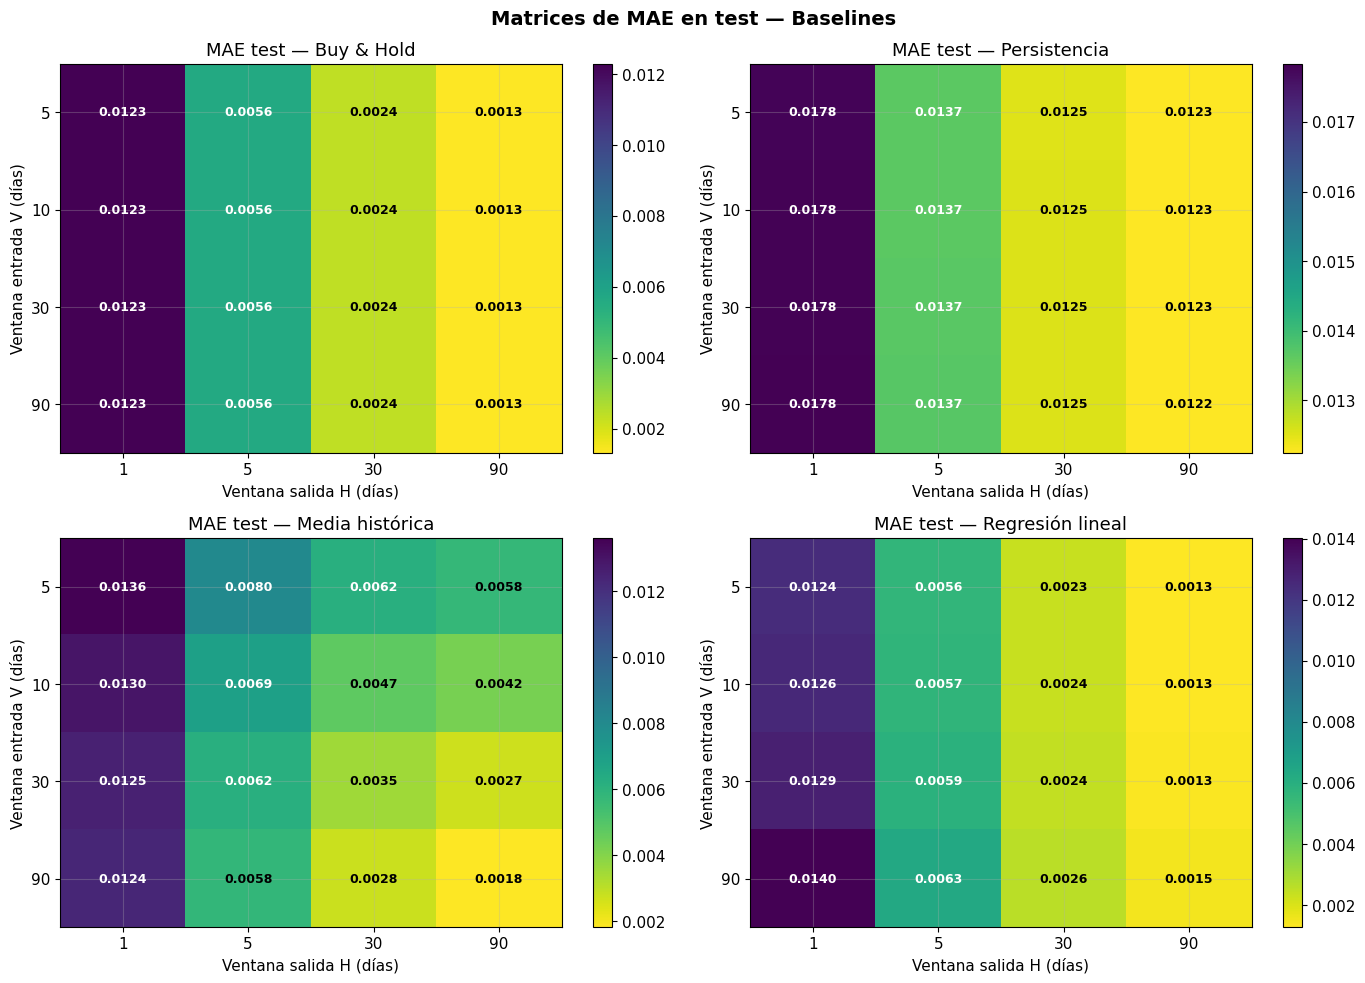

Guardado en results/figures/01_matrices_baselines.png


In [8]:
modelos = ["Buy & Hold", "Persistencia", "Media histórica", "Regresión lineal"]
figures_dir = project_root / "results" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, modelo in enumerate(modelos):
    df_modelo = df[df["modelo"] == modelo]
    resultados_modelo = df_modelo.to_dict("records")
    matriz = construir_matriz_resultados(resultados_modelo, INPUT_WINDOWS, OUTPUT_WINDOWS)

    ax = axes[idx]
    im = ax.imshow(matriz, cmap="viridis_r", origin="upper", aspect="auto")

    # Anotar valores en cada celda
    for i in range(len(INPUT_WINDOWS)):
        for j in range(len(OUTPUT_WINDOWS)):
            val = matriz[i, j]
            if not np.isnan(val):
                color = "white" if val > np.nanmedian(matriz) else "black"
                ax.text(j, i, f"{val:.4f}", ha="center", va="center",
                       color=color, fontsize=9, fontweight="bold")

    ax.set_xticks(range(len(OUTPUT_WINDOWS)))
    ax.set_yticks(range(len(INPUT_WINDOWS)))
    ax.set_xticklabels(OUTPUT_WINDOWS)
    ax.set_yticklabels(INPUT_WINDOWS)
    ax.set_xlabel("Ventana salida H (días)")
    ax.set_ylabel("Ventana entrada V (días)")
    ax.set_title(f"MAE test — {modelo}")
    plt.colorbar(im, ax=ax)

plt.suptitle("Matrices de MAE en test — Baselines", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(figures_dir / "01_matrices_baselines.png", bbox_inches="tight", dpi=120)
plt.show()
print("Guardado en results/figures/01_matrices_baselines.png")

**Observación 1: el MAE siempre baja de izquierda a derecha**

En todos los modelos, el MAE disminuye al aumentar H (de 1 a 90 días).

**¿Por qué?** Porque el target Y es un **promedio**. Al promediar 90 retornos diarios, los picos y valles se cancelan y el resultado siempre es cercano a cero. Cualquier modelo que prediga cerca de cero tendrá un MAE bajo.

> Predecir a 90 días parece más fácil, pero es menos útil. El dato que más interesa financieramente es **H=1**, que es el más difícil.

**Observación 2: Buy & Hold es el mejor o igual que todos**

Para H=90, Buy & Hold (MAE = 0.0013) empata con la Regresión lineal. Un modelo que **predice siempre cero** compite con uno que ha aprendido de 13.000 ejemplos. Esto refleja la eficiencia del mercado: el retorno promedio esperado a largo plazo es prácticamente cero.



**Observación 3: la Persistencia es el peor modelo**

Para H=1, Persistencia tiene el MAE más alto (0.0178). Decir "mañana será igual que hoy" es la peor estrategia. En finanzas los retornos tienden a **revertir a la media**, no a continuar en la misma dirección.


**Observación 4: la Regresión lineal no mejora sobre Buy & Hold**

A pesar de haber aprendido de miles de ejemplos y tener cientos de parámetros, la regresión lineal no mejora al modelo más simple. **Esto es la señal más importante**: si la regresión no aporta nada, las redes neuronales van a tener que trabajar duro para justificar su complejidad.

---

**El objetivo para las redes neuronales**

El suelo a batir para H=1 (el horizonte más relevante) es:

```
MAE red neuronal < 0.0123
```

Si una red no consigue esto de forma consistente en test, su complejidad no está justificada.

## 7. Comparación directa entre baselines

¿Qué baseline es mejor? Comparamos el MAE en test promediado sobre todas las
combinaciones de ventanas. El mejor baseline será nuestra referencia más exigente
para las redes neuronales.

In [9]:
# MAE promedio en test por modelo (sobre las 16 combinaciones)
mae_promedio = (
    df.groupby("modelo")["MAE_test"]
    .mean()
    .sort_values()
)

print("MAE promedio en test (sobre las 16 combinaciones):")
print(mae_promedio.to_string())
print()
print(f"Mejor baseline: {mae_promedio.index[0]} (MAE = {mae_promedio.iloc[0]:.6f})")
print(f"Peor baseline:  {mae_promedio.index[-1]} (MAE = {mae_promedio.iloc[-1]:.6f})")

MAE promedio en test (sobre las 16 combinaciones):
modelo
Buy & Hold          0.005390
Regresión lineal    0.005661
Media histórica     0.006880
Persistencia        0.014064

Mejor baseline: Buy & Hold (MAE = 0.005390)
Peor baseline:  Persistencia (MAE = 0.014064)


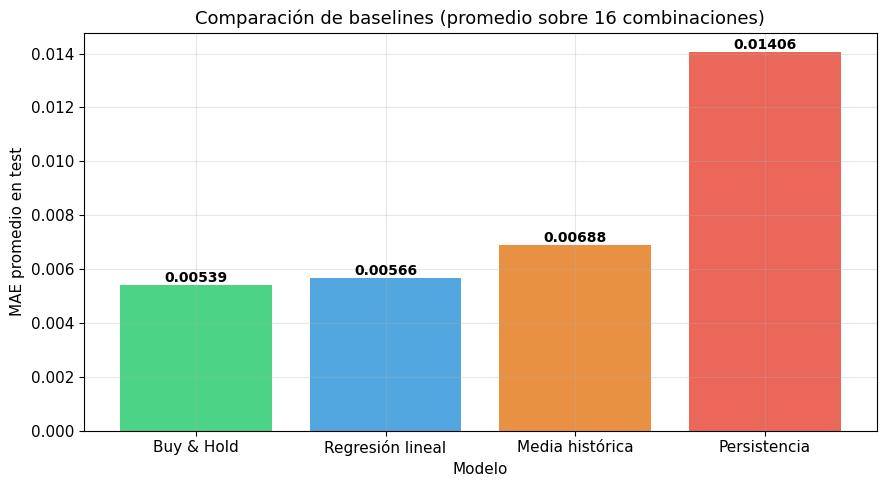

In [10]:
# Gráfica de barras comparando los 4 baselines
fig, ax = plt.subplots(figsize=(9, 5))

colores = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]
bars = ax.bar(mae_promedio.index, mae_promedio.values, color=colores, alpha=0.85)

for bar, val in zip(bars, mae_promedio.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{val:.5f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("MAE promedio en test")
ax.set_title("Comparación de baselines (promedio sobre 16 combinaciones)")
ax.set_xlabel("Modelo")
plt.tight_layout()
plt.savefig(figures_dir / "01_comparacion_baselines.png", bbox_inches="tight", dpi=120)
plt.show()

## 8. ¿Cómo cambia el MAE según el horizonte de predicción?

Esta es una de las observaciones más importantes del taller.
El profesor dijo en clase: *"cuanto más lejos predices, menor parece el MAE,
pero menos útil es la predicción"*.

Vamos a verificarlo con los datos reales.

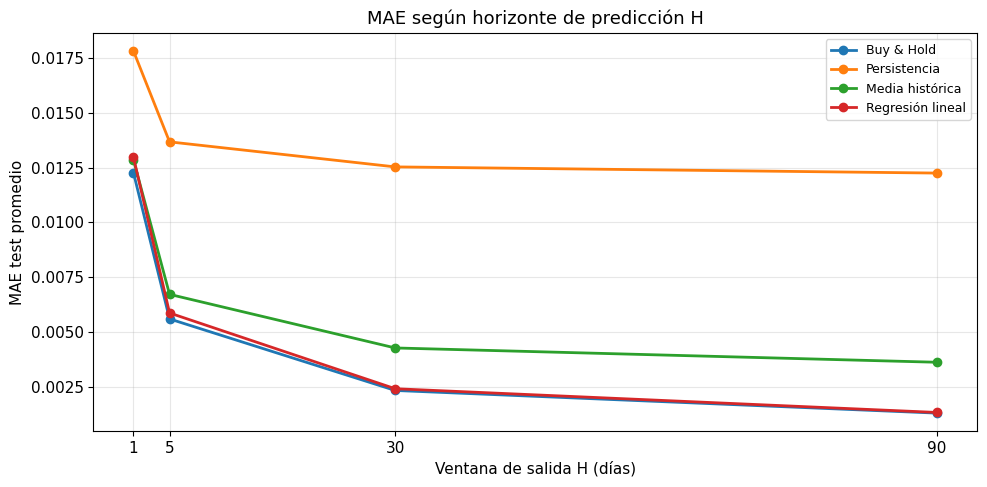


Observación: ¿el MAE baja al aumentar H? ¿Por qué crees que pasa eso?


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

for modelo in modelos:
    df_m = df[df["modelo"] == modelo]
    mae_por_H = df_m.groupby("H")["MAE_test"].mean()
    ax.plot(mae_por_H.index, mae_por_H.values, marker="o", label=modelo, linewidth=2)

ax.set_xlabel("Ventana de salida H (días)")
ax.set_ylabel("MAE test promedio")
ax.set_title("MAE según horizonte de predicción H")
ax.set_xticks(OUTPUT_WINDOWS)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "01_mae_por_horizonte.png", bbox_inches="tight", dpi=120)
plt.show()
print()
print("Observación: ¿el MAE baja al aumentar H? ¿Por qué crees que pasa eso?")

## 9. Resumen y conclusiones

Antes de continuar al notebook 02 (redes densas), reflexiona sobre estas preguntas:

**Pregunta 1**: ¿Qué baseline tiene el MAE más bajo en test? ¿Te sorprende?

**Pregunta 2**: ¿El MAE baja al aumentar H (el horizonte de predicción)?
Si es así, ¿significa que predecir a 90 días es más fácil que a 1 día?
¿O hay otra explicación?

**Pregunta 3**: Para la regresión lineal, ¿el MAE de train es mucho más bajo
que el de test? ¿Qué te dice eso sobre el sobreajuste?

**Objetivo del siguiente notebook**: construir MLPs (redes densas) que batan
consistentemente al mejor baseline. Si no lo consiguen, la complejidad añadida
no está justificada.


In [12]:
# Resumen final: tabla con los mejores resultados por combinación
print("Mejor baseline por combinación (menor MAE en test):")
print()
mejor_por_combinacion = (
    df.loc[df.groupby(["V", "H"])["MAE_test"].idxmin()]
    [["V", "H", "modelo", "MAE_test", "MAE_train"]]
    .sort_values(["V", "H"])
    .reset_index(drop=True)
)
print(mejor_por_combinacion.to_string(index=False))
print()
print("Guarda estos números: son el suelo que deben batir las redes neuronales.")

Mejor baseline por combinación (menor MAE en test):

 V  H           modelo  MAE_test  MAE_train
 5  1       Buy & Hold  0.012258   0.011668
 5  5       Buy & Hold  0.005607   0.005404
 5 30 Regresión lineal  0.002337   0.002162
 5 90 Regresión lineal  0.001274   0.001241
10  1       Buy & Hold  0.012262   0.011669
10  5       Buy & Hold  0.005607   0.005405
10 30 Regresión lineal  0.002354   0.002152
10 90 Regresión lineal  0.001284   0.001237
30  1       Buy & Hold  0.012269   0.011671
30  5       Buy & Hold  0.005611   0.005405
30 30       Buy & Hold  0.002355   0.002218
30 90       Buy & Hold  0.001324   0.001315
90  1       Buy & Hold  0.012287   0.011677
90  5       Buy & Hold  0.005619   0.005408
90 30       Buy & Hold  0.002356   0.002212
90 90       Buy & Hold  0.001326   0.001310

Guarda estos números: son el suelo que deben batir las redes neuronales.
